In [1]:
# ==========================================================
# Cell 1 - Import Libraries
# ==========================================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("="*60)
print("Notebook 6 Started")
print("="*60)

Notebook 6 Started


In [2]:
# ==========================================================
# Cell 2 - Load Dataset
# ==========================================================

from pathlib import Path

PROJECT_DIR = Path("/Users/rajdeepmandal/Desktop/PrithviX")
PROCESSED_DIR = PROJECT_DIR / "Processed"

dataset = pd.read_csv(
    PROCESSED_DIR / "training_dataset.csv"
)

print(dataset.shape)

display(dataset.head())

(50931, 5)


,DEM,NDVI,Soil,Population,Landslide
0,61.0,0.414891,0.0,8.558760,0
1,86.0,0.879887,0.0,0.856890,0
2,255.0,0.574537,0.0,5.735787,0
3,1895.0,0.876970,0.0,0.014362,0
4,600.0,0.883863,0.0,0.651973,0


In [3]:
# ==========================================================
# Cell 3 - Split Dataset
# ==========================================================

X = dataset.drop(columns=["Landslide"])

y = dataset["Landslide"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (40744, 4)
Testing  : (10187, 4)


In [4]:
 # ==========================================================
# Cell 4 - Train Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("="*60)
print("Training Random Forest...")
print("="*60)

rf.fit(X_train, y_train)

print("Training Complete!")

Training Random Forest...
Training Complete!


In [5]:
# ==========================================================
# Cell 5 - Evaluate Model
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

MODEL PERFORMANCE
Accuracy : 0.9835
Precision: 0.5378
Recall   : 0.6882
F1 Score : 0.6038
ROC AUC  : 0.9734

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10001
           1       0.54      0.69      0.60       186

    accuracy                           0.98     10187
   macro avg       0.77      0.84      0.80     10187
weighted avg       0.99      0.98      0.98     10187


Confusion Matrix

[[9891  110]
 [  58  128]]


,Feature,Importance
3,Population,0.431323
0,DEM,0.423738
1,NDVI,0.144939
2,Soil,0.000000


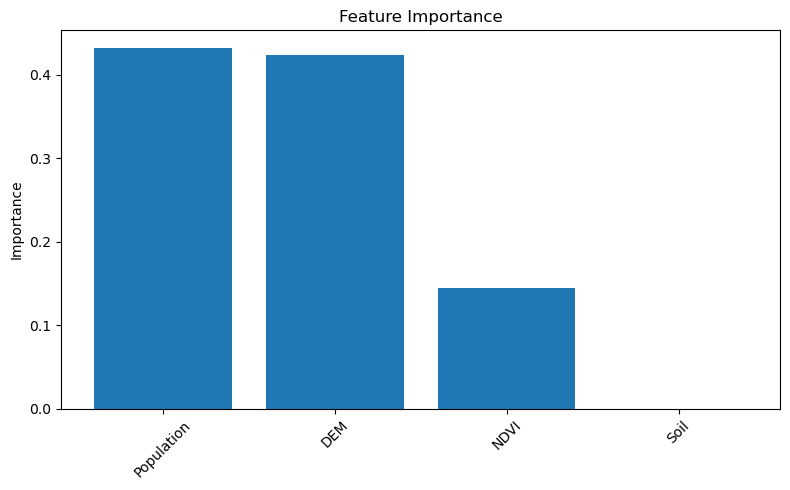

In [6]:
# ==========================================================
# Cell 6 - Feature Importance
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# ==========================================================
# Cell 7 - Save Model
# ==========================================================

import joblib

MODEL_DIR = PROJECT_DIR / "Models"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "landslide_rf.pkl"

joblib.dump(rf, model_path)

print("="*60)
print("MODEL SAVED")
print("="*60)
print(model_path)

MODEL SAVED
/Users/rajdeepmandal/Desktop/PrithviX/Models/landslide_rf.pkl
